In [3]:
!pip install -q opendatasets librosa scikit-image torchsummary

In [4]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


#  Dataset Download

For this project, we use the UrbanSound8K dataset for environmental sound classification.

UrbanSound8K contains 8,732 labeled audio recordings belonging to 10 environmental sound categories. The recordings are provided as WAV files and are organized into 10 predefined folds.

The predefined folds are important because they allow consistent and reproducible evaluation. Therefore, unlike the reference notebook, we will preserve the original fold structure instead of randomly reshuffling the dataset.

The dataset will be downloaded directly from Kaggle using the Kaggle API credentials (`kaggle.json`) provided by the user.

In [2]:
!pip install -q kaggle

In [5]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [7]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle datasets download -d chrisfilo/urbansound8k

Dataset URL: https://www.kaggle.com/datasets/chrisfilo/urbansound8k
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 5.61G/5.61G [04:36<00:00, 21.8MB/s]



In [8]:
!unzip -q urbansound8k.zip -d /content/

In [9]:
!ls -lah /content/

total 5.7G
drwxr-xr-x 1 root root 4.0K Sep  7 16:40 .
drwxr-xr-x 1 root root 4.0K Sep  7 16:20 ..
drwxr-xr-x 4 root root 4.0K Aug 24 13:27 .config
drwxr-xr-x 2 root root  36K Sep  7 16:39 fold1
drwxr-xr-x 2 root root  36K Sep  7 16:39 fold10
drwxr-xr-x 2 root root  36K Sep  7 16:39 fold2
drwxr-xr-x 2 root root  36K Sep  7 16:39 fold3
drwxr-xr-x 2 root root  36K Sep  7 16:39 fold4
drwxr-xr-x 2 root root  36K Sep  7 16:40 fold5
drwxr-xr-x 2 root root  36K Sep  7 16:40 fold6
drwxr-xr-x 2 root root  36K Sep  7 16:40 fold7
drwxr-xr-x 2 root root  36K Sep  7 16:40 fold8
drwxr-xr-x 2 root root  36K Sep  7 16:40 fold9
-rw-r--r-- 1 root root   65 Sep  7 16:33 kaggle.json
drwxr-xr-x 1 root root 4.0K Aug 24 13:28 sample_data
-rw-r--r-- 1 root root 483K Feb  4  2020 UrbanSound8K.csv
-rw-r--r-- 1 root root 5.7G Feb  4  2020 urbansound8k.zip


In [10]:
!find /content -maxdepth 2 -type d | head -50

/content
/content/.config
/content/.config/configurations
/content/.config/logs
/content/fold2
/content/fold6
/content/fold3
/content/fold7
/content/fold9
/content/fold10
/content/fold1
/content/fold5
/content/fold4
/content/fold8
/content/sample_data


In [11]:
!rm /content/urbansound8k.zip

In [12]:
!du -sh /content/fold*

772M	/content/fold1
669M	/content/fold10
702M	/content/fold2
635M	/content/fold3
771M	/content/fold4
684M	/content/fold5
553M	/content/fold6
647M	/content/fold7
685M	/content/fold8
669M	/content/fold9


In [13]:
import pandas as pd

metadata_path = "/content/UrbanSound8K.csv"

data_df = pd.read_csv(metadata_path)

print("Dataset shape:", data_df.shape)
print("\nColumns:")
print(data_df.columns.tolist())

data_df.head()

Dataset shape: (8732, 8)

Columns:
['slice_file_name', 'fsID', 'start', 'end', 'salience', 'fold', 'classID', 'class']


,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


In [14]:
print("Number of classes:", data_df["class"].nunique())

print("\nClasses:")
print(sorted(data_df["class"].unique()))

Number of classes: 10

Classes:
['air_conditioner', 'car_horn', 'children_playing', 'dog_bark', 'drilling', 'engine_idling', 'gun_shot', 'jackhammer', 'siren', 'street_music']


In [15]:
print("\nClass distribution:")
print(data_df["class"].value_counts().sort_index())


Class distribution:
class
air_conditioner     1000
car_horn             429
children_playing    1000
dog_bark            1000
drilling            1000
engine_idling       1000
gun_shot             374
jackhammer          1000
siren                929
street_music        1000
Name: count, dtype: int64


In [16]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8732 entries, 0 to 8731
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   slice_file_name  8732 non-null   object 
 1   fsID             8732 non-null   int64  
 2   start            8732 non-null   float64
 3   end              8732 non-null   float64
 4   salience         8732 non-null   int64  
 5   fold             8732 non-null   int64  
 6   classID          8732 non-null   int64  
 7   class            8732 non-null   object 
dtypes: float64(2), int64(4), object(2)
memory usage: 545.9+ KB


In [17]:
print(data_df["fold"].value_counts().sort_index())

fold
1     873
2     888
3     925
4     990
5     936
6     823
7     838
8     806
9     816
10    837
Name: count, dtype: int64


In [18]:
print(data_df[["slice_file_name", "fold", "classID", "class"]].head(10))

      slice_file_name  fold  classID             class
0    100032-3-0-0.wav     5        3          dog_bark
1  100263-2-0-117.wav     5        2  children_playing
2  100263-2-0-121.wav     5        2  children_playing
3  100263-2-0-126.wav     5        2  children_playing
4  100263-2-0-137.wav     5        2  children_playing
5  100263-2-0-143.wav     5        2  children_playing
6  100263-2-0-161.wav     5        2  children_playing
7    100263-2-0-3.wav     5        2  children_playing
8   100263-2-0-36.wav     5        2  children_playing
9    100648-1-0-0.wav    10        1          car_horn


#  Audio File Verification

In [19]:
from pathlib import Path

AUDIO_ROOT = Path("/content")

sample = data_df.iloc[0]

audio_path = AUDIO_ROOT / f"fold{sample['fold']}" / sample["slice_file_name"]

print("Filename:", sample["slice_file_name"])
print("Fold:", sample["fold"])
print("Class:", sample["class"])
print("Audio path:", audio_path)
print("File exists:", audio_path.exists())

Filename: 100032-3-0-0.wav
Fold: 5
Class: dog_bark
Audio path: /content/fold5/100032-3-0-0.wav
File exists: True


In [20]:
import librosa

signal, sample_rate = librosa.load(audio_path, sr=None)

print("Sample rate:", sample_rate)
print("Number of samples:", len(signal))
print("Duration:", len(signal) / sample_rate, "seconds")

Sample rate: 44100
Number of samples: 14004
Duration: 0.31755102040816324 seconds


**Visualize the Waveform**

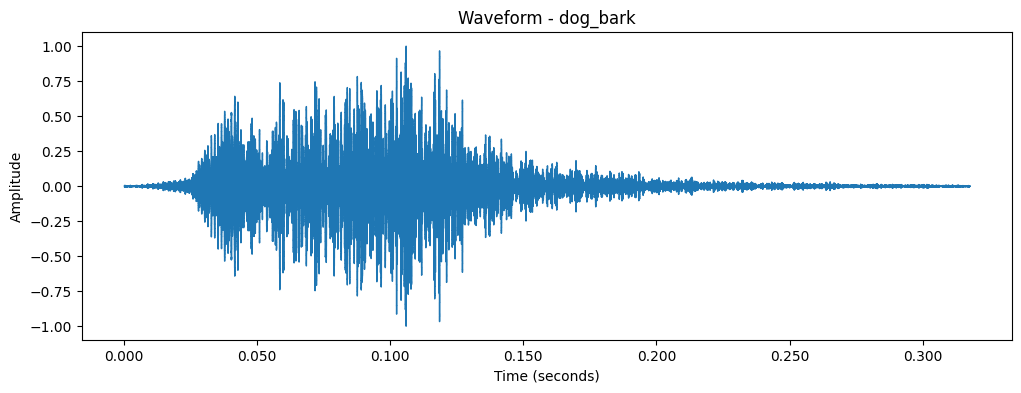

In [21]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(12, 4))

librosa.display.waveshow(signal, sr=sample_rate)

plt.title(f"Waveform - {sample['class']}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

# Mel Spectrogram Generation

A waveform represents an audio signal in the time domain. For CNN-based audio classification, we convert the waveform into a two-dimensional time-frequency representation.

A Mel spectrogram represents the distribution of sound energy across Mel-frequency bands over time.

The transformation follows:

Audio waveform → STFT → Mel filter bank → Mel spectrogram

The resulting representation can be treated as a two-dimensional feature map and provided to a CNN.

In this step, we generate a Mel spectrogram from one UrbanSound8K recording and visualize it before building the complete preprocessing pipeline.

In [22]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

mel_spec = librosa.feature.melspectrogram(
    y=signal,
    sr=sample_rate,
    n_fft=2048,
    hop_length=512,
    n_mels=128
)

print("Mel spectrogram shape:", mel_spec.shape)

Mel spectrogram shape: (128, 28)


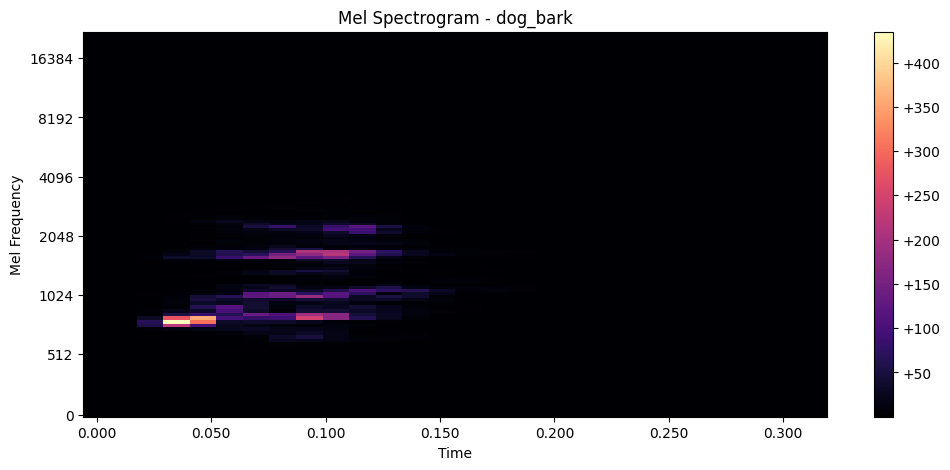

In [23]:
plt.figure(figsize=(12, 5))

librosa.display.specshow(
    mel_spec,
    sr=sample_rate,
    hop_length=512,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f")
plt.title(f"Mel Spectrogram - {sample['class']}")
plt.xlabel("Time")
plt.ylabel("Mel Frequency")

plt.show()

# Convert Mel Spectrogram to Decibels

The raw Mel spectrogram represents the power of different Mel-frequency bands over time.

However, the raw power values can have a large dynamic range. To obtain a more practical representation, we convert the power values into a logarithmic decibel (dB) scale.

The conversion is performed using `librosa.power_to_db()`.

This produces a log-scaled Mel spectrogram that is easier to visualize and provides a more suitable representation for subsequent machine learning processing.

The preprocessing pipeline is therefore:

Waveform → Mel Spectrogram → Log-Mel Spectrogram

In [24]:
mel_spec_db = librosa.power_to_db(
    mel_spec,
    ref=np.max
)

print("Log-Mel spectrogram shape:", mel_spec_db.shape)
print("Minimum dB:", mel_spec_db.min())
print("Maximum dB:", mel_spec_db.max())

Log-Mel spectrogram shape: (128, 28)
Minimum dB: -80.0
Maximum dB: 0.0


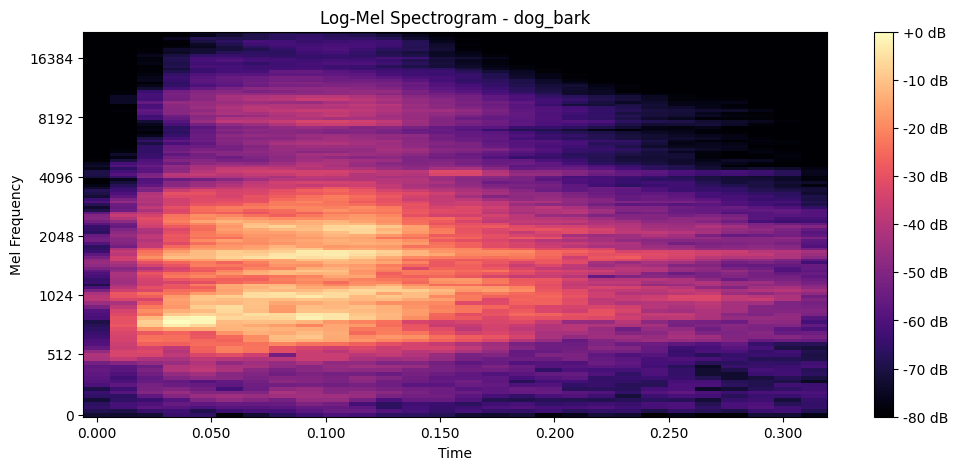

In [25]:
plt.figure(figsize=(12, 5))

librosa.display.specshow(
    mel_spec_db,
    sr=sample_rate,
    hop_length=512,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title(f"Log-Mel Spectrogram - {sample['class']}")
plt.xlabel("Time")
plt.ylabel("Mel Frequency")

plt.show()

# Standardizing Audio Duration

UrbanSound8K contains audio clips with varying durations. Since a CNN requires inputs with consistent dimensions, the audio signals must be standardized before feature extraction.

Instead of resizing the Mel spectrogram, the waveform will be standardized directly in the time domain.

A fixed target duration will be used:

- Audio shorter than the target duration → zero-padded
- Audio longer than the target duration → trimmed
- Audio equal to the target duration → unchanged

This preserves the original time-frequency structure of the audio more naturally than resizing the extracted spectrogram.

The standardized waveform will then be converted into a Mel spectrogram.

In [27]:
import librosa
import numpy as np

# Audio preprocessing parameters
TARGET_SR = 22050
TARGET_DURATION = 4

# Number of samples corresponding to the target duration
TARGET_SAMPLES = TARGET_SR * TARGET_DURATION

# Load the sample audio at the target sampling rate
signal, sample_rate = librosa.load(
    audio_path,
    sr=TARGET_SR,
    mono=True
)

print("Original sample rate:", sample_rate)
print("Original number of samples:", len(signal))
print("Original duration:", len(signal) / sample_rate)

# Pad or trim the waveform
signal_fixed = librosa.util.fix_length(
    signal,
    size=TARGET_SAMPLES
)

print("\nAfter padding/trimming:")
print("Sample rate:", sample_rate)
print("Number of samples:", len(signal_fixed))
print("Duration:", len(signal_fixed) / sample_rate)

Original sample rate: 22050
Original number of samples: 7002
Original duration: 0.31755102040816324

After padding/trimming:
Sample rate: 22050
Number of samples: 88200
Duration: 4.0


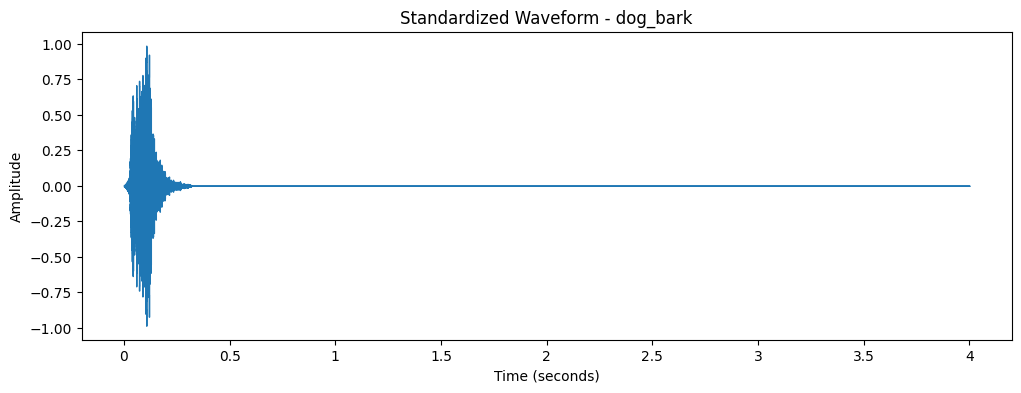

In [28]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(12, 4))

librosa.display.waveshow(
    signal_fixed,
    sr=sample_rate
)

plt.title(f"Standardized Waveform - {sample['class']}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

# Analyzing Audio Duration Distribution

Before selecting a fixed duration for padding and trimming, we first examine the duration distribution of the complete dataset.

The duration of each UrbanSound8K clip can be obtained from its metadata using:

    duration = end - start

Understanding the minimum, maximum, mean, median, and percentile durations will help us choose an appropriate target duration rather than arbitrarily padding every recording to four seconds.

In [29]:
# Calculate duration of every audio clip
data_df["duration"] = data_df["end"] - data_df["start"]

# Display basic statistics
print(data_df["duration"].describe())

# Display selected percentiles
print("\nSelected percentiles:")
print("25th percentile:", data_df["duration"].quantile(0.25))
print("50th percentile (median):", data_df["duration"].quantile(0.50))
print("75th percentile:", data_df["duration"].quantile(0.75))
print("90th percentile:", data_df["duration"].quantile(0.90))
print("95th percentile:", data_df["duration"].quantile(0.95))
print("99th percentile:", data_df["duration"].quantile(0.99))

count    8732.000000
mean        3.607904
std         0.973570
min         0.054517
25%         4.000000
50%         4.000000
75%         4.000000
max         4.000000
Name: duration, dtype: float64

Selected percentiles:
25th percentile: 4.0
50th percentile (median): 4.0
75th percentile: 4.0
90th percentile: 4.0
95th percentile: 4.0
99th percentile: 4.000000000000002


In [30]:
shorter_than_4 = (data_df["duration"] < 4.0).sum()
exactly_4 = (data_df["duration"] == 4.0).sum()

print("Clips shorter than 4 seconds:", shorter_than_4)
print("Clips exactly 4 seconds:", exactly_4)

print(
    "Percentage shorter than 4 seconds:",
    shorter_than_4 / len(data_df) * 100
)

print(
    "Percentage exactly 4 seconds:",
    exactly_4 / len(data_df) * 100
)

Clips shorter than 4 seconds: 1655
Clips exactly 4 seconds: 6864
Percentage shorter than 4 seconds: 18.953275309207513
Percentage exactly 4 seconds: 78.60742098030234


In [31]:
exactly_4 = np.isclose(
    data_df["duration"],
    4.0
).sum()

shorter_than_4 = (
    data_df["duration"] < 4.0
).sum()

print("Clips shorter than 4 seconds:", shorter_than_4)
print("Clips exactly 4 seconds:", exactly_4)

print(
    "Percentage shorter than 4 seconds:",
    shorter_than_4 / len(data_df) * 100
)

print(
    "Percentage exactly 4 seconds:",
    exactly_4 / len(data_df) * 100
)

Clips shorter than 4 seconds: 1655
Clips exactly 4 seconds: 7333
Percentage shorter than 4 seconds: 18.953275309207513
Percentage exactly 4 seconds: 83.97846999541915


# Extracting the Mel Spectrogram

The standardized four-second waveform is converted into a Mel spectrogram.

A Mel spectrogram represents the distribution of audio energy across time and perceptually motivated frequency bands.

The waveform is analyzed using short overlapping windows. Each window is transformed into the frequency domain, and the resulting frequency information is mapped onto Mel-frequency bands.

The resulting two-dimensional representation will later be treated as an image-like input by the CNN.

In [32]:
# Mel spectrogram parameters
N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128

# Generate Mel spectrogram from the standardized waveform
mel_spec = librosa.feature.melspectrogram(
    y=signal_fixed,
    sr=sample_rate,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS
)

print("Mel spectrogram shape:", mel_spec.shape)

Mel spectrogram shape: (128, 173)


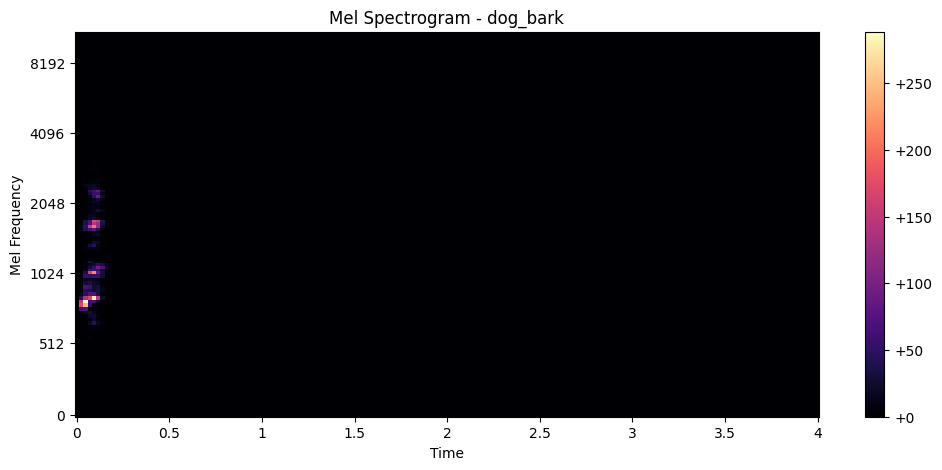

In [33]:
plt.figure(figsize=(12, 5))

librosa.display.specshow(
    mel_spec,
    sr=sample_rate,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f")
plt.title(f"Mel Spectrogram - {sample['class']}")
plt.xlabel("Time")
plt.ylabel("Mel Frequency")

plt.show()

In [34]:
# Convert Mel spectrogram from power to decibel scale
mel_spec_db = librosa.power_to_db(
    mel_spec,
    ref=np.max
)

print("Log-Mel spectrogram shape:", mel_spec_db.shape)
print("Minimum dB:", mel_spec_db.min())
print("Maximum dB:", mel_spec_db.max())

Log-Mel spectrogram shape: (128, 173)
Minimum dB: -80.0
Maximum dB: 0.0


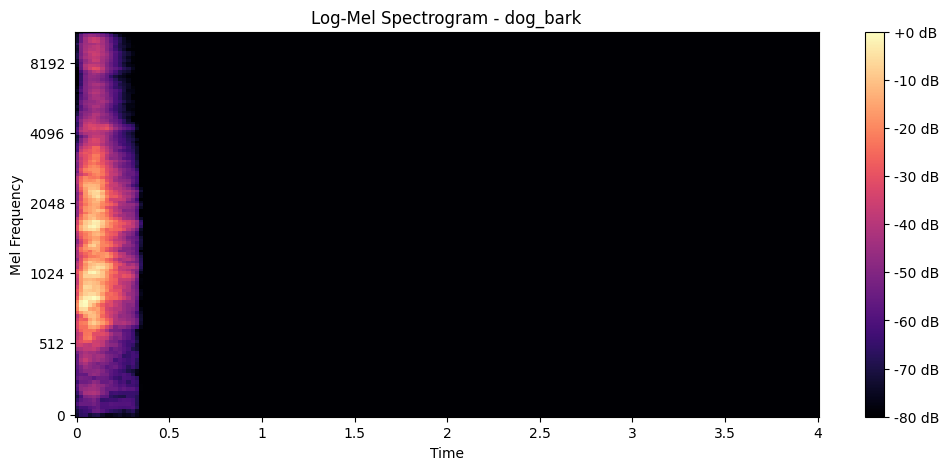

In [35]:
plt.figure(figsize=(12, 5))

librosa.display.specshow(
    mel_spec_db,
    sr=sample_rate,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title(f"Log-Mel Spectrogram - {sample['class']}")
plt.xlabel("Time")
plt.ylabel("Mel Frequency")

plt.show()

# Converting the Spectrogram to a PyTorch Tensor

The log-Mel spectrogram is currently stored as a NumPy array with shape:

    (Mel bands, time frames)

For our CNN, we need an explicit channel dimension, just as an image has a channel dimension.

Since a Mel spectrogram is represented as a single-channel input, its shape will be converted from:

    (128, 173)

to:

    (1, 128, 173)

The resulting NumPy array will then be converted into a PyTorch tensor so that it can be processed by the neural network.

In [36]:
import torch

# Add a channel dimension
mel_spec_tensor = torch.tensor(
    mel_spec_db,
    dtype=torch.float32
).unsqueeze(0)

print("Tensor shape:", mel_spec_tensor.shape)
print("Tensor dtype:", mel_spec_tensor.dtype)

Tensor shape: torch.Size([1, 128, 173])
Tensor dtype: torch.float32


# Normalizing the Log-Mel Spectrogram

The log-Mel spectrogram currently contains values in decibels, ranging from approximately -80 dB to 0 dB.

To provide the CNN with a more convenient numerical range, the values are normalized to [0, 1].

This normalization does not change the time-frequency structure of the spectrogram. It only rescales its numerical values.

In [37]:
# Normalize log-Mel spectrogram to the range [0, 1]

mel_spec_normalized = (
    mel_spec_db - mel_spec_db.min()
) / (
    mel_spec_db.max() - mel_spec_db.min()
)

print("Minimum:", mel_spec_normalized.min())
print("Maximum:", mel_spec_normalized.max())
print("Shape:", mel_spec_normalized.shape)

Minimum: 0.0
Maximum: 1.0
Shape: (128, 173)


In [38]:
mel_spec_tensor = torch.tensor(
    mel_spec_normalized,
    dtype=torch.float32
).unsqueeze(0)

print("Final tensor shape:", mel_spec_tensor.shape)
print("Final tensor dtype:", mel_spec_tensor.dtype)

Final tensor shape: torch.Size([1, 128, 173])
Final tensor dtype: torch.float32


# Creating the Audio Dataset

The preprocessing steps developed above will now be incorporated into a PyTorch Dataset.

For each audio sample, the Dataset will:

1. Locate the audio file using its fold and filename.
2. Load the audio at the target sampling rate.
3. Convert it to mono.
4. Pad or trim it to four seconds.
5. Generate a Mel spectrogram.
6. Convert the Mel spectrogram to decibel scale.
7. Normalize the spectrogram to [0, 1].
8. Add the channel dimension required by the CNN.

The Dataset will return:

    spectrogram, label

where the spectrogram has the shape:

    [1, 128, 173]

In [39]:
import torch
from torch.utils.data import Dataset
import librosa
import numpy as np


class UrbanSoundDataset(Dataset):

    def __init__(
        self,
        dataframe,
        audio_root="/content",
        target_sr=22050,
        target_duration=4,
        n_fft=2048,
        hop_length=512,
        n_mels=128
    ):

        self.dataframe = dataframe.reset_index(drop=True)
        self.audio_root = audio_root

        self.target_sr = target_sr
        self.target_duration = target_duration
        self.target_samples = target_sr * target_duration

        self.n_fft = n_fft
        self.hop_length = hop_length
        self.n_mels = n_mels

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        # Get metadata
        row = self.dataframe.iloc[index]

        # Construct audio path
        audio_path = (
            f"{self.audio_root}/fold{row['fold']}/{row['slice_file_name']}"
        )

        # Load audio
        signal, sample_rate = librosa.load(
            audio_path,
            sr=self.target_sr,
            mono=True
        )

        # Pad or trim to fixed duration
        signal = librosa.util.fix_length(
            signal,
            size=self.target_samples
        )

        # Generate Mel spectrogram
        mel_spec = librosa.feature.melspectrogram(
            y=signal,
            sr=sample_rate,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            n_mels=self.n_mels
        )

        # Convert power spectrogram to dB
        mel_spec_db = librosa.power_to_db(
            mel_spec,
            ref=np.max
        )

        # Normalize to [0, 1]
        mel_spec_normalized = (
            mel_spec_db - mel_spec_db.min()
        ) / (
            mel_spec_db.max() - mel_spec_db.min()
        )

        # Convert to PyTorch tensor and add channel dimension
        mel_spec_tensor = torch.tensor(
            mel_spec_normalized,
            dtype=torch.float32
        ).unsqueeze(0)

        # Get label
        label = int(row["classID"])

        return mel_spec_tensor, label

In [40]:
dataset = UrbanSoundDataset(data_df)

spectrogram, label = dataset[0]

print("Spectrogram shape:", spectrogram.shape)
print("Spectrogram dtype:", spectrogram.dtype)
print("Label:", label)

Spectrogram shape: torch.Size([1, 128, 173])
Spectrogram dtype: torch.float32
Label: 3


# Creating Training and Test DataLoaders

UrbanSound8K provides predefined folds for evaluation.

To preserve the dataset's intended evaluation protocol, the audio samples will be divided according to these predefined folds rather than randomly splitting individual recordings.

For the initial experiment:

- Folds 1–9 → Training set
- Fold 10 → Test set

The PyTorch DataLoader will group individual spectrograms into batches for efficient model training.

Training data will be shuffled, while test data will not be shuffled.

In [56]:
from sklearn.model_selection import train_test_split

development_df = data_df[data_df["fold"].isin(range(1, 10))].reset_index(drop=True)

test_df = data_df[data_df["fold"] == 10].reset_index(drop=True)

train_df, val_df = train_test_split(
    development_df,
    test_size=0.15,
    stratify=development_df["classID"],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

# Creating PyTorch DataLoaders

In [57]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

# Create datasets
train_dataset = UrbanSoundDataset(train_df)
val_dataset = UrbanSoundDataset(val_df)
test_dataset = UrbanSoundDataset(test_df)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training samples: 6710
Validation samples: 1185
Test samples: 837
Training batches: 210
Validation batches: 38
Test batches: 27


In [58]:
images, labels = next(iter(train_loader))

print("Batch spectrogram shape:", images.shape)
print("Batch labels shape:", labels.shape)
print("Labels:", labels)

Batch spectrogram shape: torch.Size([32, 1, 128, 173])
Batch labels shape: torch.Size([32])
Labels: tensor([8, 4, 2, 0, 0, 9, 2, 7, 0, 3, 2, 4, 3, 3, 5, 8, 7, 0, 3, 9, 3, 1, 5, 1,
        0, 0, 5, 6, 8, 4, 4, 4])


# Building the Convolutional Neural Network

The log-Mel spectrogram is treated as a single-channel two-dimensional input.

The CNN progressively extracts increasingly meaningful audio patterns through convolutional layers.

The architecture consists of:

- Convolutional layers for feature extraction
- ReLU activation for non-linearity
- Max pooling for spatial downsampling
- Dropout for regularization
- Adaptive average pooling to produce a fixed-size feature representation
- Fully connected layers for classification

The network produces 10 output logits, corresponding to the 10 UrbanSound8K sound classes.

In [59]:
import torch
import torch.nn as nn


class AudioCNN(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.2),

            # Block 2
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.2),

            # Block 3
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.2)
        )

        # Convert the variable spatial representation
        # into a fixed-size feature representation
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)

        return x

In [61]:
model = AudioCNN(num_classes=10)

print(model)

AudioCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.2, inplace=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.2, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Dropout(p=0.2, inplace=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [62]:
# Use one training batch to test the forward pass

images, labels = next(iter(train_loader))

outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([32, 1, 128, 173])
Output shape: torch.Size([32, 10])


# Configuring the Training Process

The CNN now produces 10 output logits for each audio sample.

For multi-class classification, CrossEntropyLoss will compare these logits with the corresponding class labels and calculate the classification error.

The Adam optimizer will update the model parameters based on the gradients calculated during backpropagation.

Training will use the available GPU when CUDA is available.

In [63]:
import torch
import torch.nn as nn
from torch.optim import Adam

# Select device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

# Move model to device
model = model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = Adam(
    model.parameters(),
    lr=0.001
)

Device: cuda


# Handling Class Imbalance with Weighted Cross-Entropy Loss

In [64]:
# Count samples belonging to each class in the training set
class_counts = (
    train_df["classID"]
    .value_counts()
    .sort_index()
)

print("Training samples per class:")
print(class_counts)

Training samples per class:
classID
0    765
1    336
2    765
3    765
4    765
5    771
6    291
7    768
8    719
9    765
Name: count, dtype: int64


In [65]:
num_classes = 10
total_samples = len(train_df)

class_weights = total_samples / (
    num_classes * class_counts
)

print("\nClass weights:")
print(class_weights)


Class weights:
classID
0    0.877124
1    1.997024
2    0.877124
3    0.877124
4    0.877124
5    0.870298
6    2.305842
7    0.873698
8    0.933241
9    0.877124
Name: count, dtype: float64


In [66]:
class_weights_tensor = torch.tensor(
    class_weights.values,
    dtype=torch.float32
)

print("\nWeight tensor:")
print(class_weights_tensor)


Weight tensor:
tensor([0.8771, 1.9970, 0.8771, 0.8771, 0.8771, 0.8703, 2.3058, 0.8737, 0.9332,
        0.8771])


In [67]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor.to(device)
)

print("Class-weighted CrossEntropyLoss configured.")

Class-weighted CrossEntropyLoss configured.


# Validation Function

After each training epoch, the model is evaluated on the validation set.

The model is switched to evaluation mode so that dropout behaves appropriately during validation.

Gradient computation is disabled because the model parameters are not being updated during validation.

Validation loss and accuracy are used to determine whether the current model is the best checkpoint so far.

In [68]:
def evaluate(model, dataloader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            total += labels.size(0)

            correct += (
                predictions == labels
            ).sum().item()

    average_loss = running_loss / len(dataloader)

    accuracy = 100 * correct / total

    return average_loss, accuracy

# Training the CNN with Checkpoint Selection

The CNN will be trained for multiple epochs.

After every epoch:

1. Training loss and accuracy are calculated.
2. Validation loss and accuracy are calculated.
3. The current validation accuracy is compared with the best validation accuracy obtained so far.
4. If the current model performs better, its model state and optimizer state are saved.

The final test set is not used during training or checkpoint selection.

This allows the best-performing validation model to be restored later for final evaluation.

In [69]:
import os

NUM_EPOCHS = 15

CHECKPOINT_PATH = "/content/best_audio_cnn.pth"

best_val_accuracy = 0.0
best_epoch = 0

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []


for epoch in range(NUM_EPOCHS):

    # -------------------------
    # Training
    # -------------------------

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(
            outputs,
            labels
        )

        # Backpropagation
        loss.backward()

        # Update parameters
        optimizer.step()

        # Accumulate loss
        running_loss += loss.item()

        # Predictions
        predictions = outputs.argmax(dim=1)

        total += labels.size(0)

        correct += (
            predictions == labels
        ).sum().item()

    train_loss = (
        running_loss /
        len(train_loader)
    )

    train_accuracy = (
        100 * correct / total
    )


    # -------------------------
    # Validation
    # -------------------------

    val_loss, val_accuracy = evaluate(
        model,
        val_loader,
        criterion,
        device
    )


    # Store metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)


    # -------------------------
    # Save best checkpoint
    # -------------------------

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1

        torch.save(
            {
                "epoch": best_epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "train_loss":
                    train_loss,

                "train_accuracy":
                    train_accuracy,

                "val_loss":
                    val_loss,

                "val_accuracy":
                    val_accuracy
            },
            CHECKPOINT_PATH
        )

        checkpoint_status = " <-- Best checkpoint saved"

    else:

        checkpoint_status = ""


    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.2f}%"
        f"{checkpoint_status}"
    )


print("\nTraining complete.")
print("Best epoch:", best_epoch)
print("Best validation accuracy:", f"{best_val_accuracy:.2f}%")
print("Checkpoint:", CHECKPOINT_PATH)

Epoch [1/15] Train Loss: 2.1252 Train Acc: 16.18% | Val Loss: 2.0348 Val Acc: 18.48% <-- Best checkpoint saved
Epoch [2/15] Train Loss: 1.9819 Train Acc: 21.25% | Val Loss: 1.8693 Val Acc: 24.30% <-- Best checkpoint saved
Epoch [3/15] Train Loss: 1.8821 Train Acc: 24.86% | Val Loss: 1.8126 Val Acc: 27.59% <-- Best checkpoint saved
Epoch [4/15] Train Loss: 1.8122 Train Acc: 27.53% | Val Loss: 1.7537 Val Acc: 31.14% <-- Best checkpoint saved
Epoch [5/15] Train Loss: 1.7514 Train Acc: 30.57% | Val Loss: 1.7238 Val Acc: 32.41% <-- Best checkpoint saved
Epoch [6/15] Train Loss: 1.6927 Train Acc: 32.40% | Val Loss: 1.6303 Val Acc: 34.09% <-- Best checkpoint saved
Epoch [7/15] Train Loss: 1.6447 Train Acc: 34.23% | Val Loss: 1.5873 Val Acc: 35.27% <-- Best checkpoint saved
Epoch [8/15] Train Loss: 1.6169 Train Acc: 35.20% | Val Loss: 1.5494 Val Acc: 36.20% <-- Best checkpoint saved
Epoch [9/15] Train Loss: 1.5784 Train Acc: 36.39% | Val Loss: 1.5166 Val Acc: 36.54% <-- Best checkpoint saved
E

**Load The Best Model Checkpoint**

In [70]:
# Load the best checkpoint
checkpoint = torch.load(
    "/content/best_audio_cnn.pth",
    map_location=device,
    weights_only=True
)

# Restore model weights
model.load_state_dict(checkpoint["model_state_dict"])

# Restore optimizer state
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

# Retrieve checkpoint information
best_epoch = checkpoint["epoch"]
best_val_accuracy = checkpoint["val_accuracy"]

print("Best epoch:", best_epoch)
print(f"Best validation accuracy: {best_val_accuracy:.2f}%")

Best epoch: 15
Best validation accuracy: 50.30%


## Final Evaluation on the Test Set

In [71]:
# Evaluate the best model on the untouched test set
test_loss, test_accuracy = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 1.3187
Test Accuracy: 47.07%


## Detailed Test Set Evaluation

Overall accuracy provides a single summary of model performance, but it does
not show how the model performs on individual sound classes.

Precision, recall, and F1-score are calculated for each UrbanSound8K class,
and a confusion matrix is used to visualize which classes are frequently
confused with one another.

In [72]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Put model in evaluation mode
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert to NumPy arrays
all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

# Class names
class_names = [
    "air_conditioner",
    "car_horn",
    "children_playing",
    "dog_bark",
    "drilling",
    "engine_idling",
    "gun_shot",
    "jackhammer",
    "siren",
    "street_music"
]

# Classification report
print("Classification Report:\n")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4
    )
)

Classification Report:

                  precision    recall  f1-score   support

 air_conditioner     0.3350    0.6600    0.4444       100
        car_horn     0.4773    0.6364    0.5455        33
children_playing     0.4024    0.3300    0.3626       100
        dog_bark     0.8222    0.3700    0.5103       100
        drilling     0.6974    0.5300    0.6023       100
   engine_idling     0.3000    0.0968    0.1463        93
        gun_shot     0.5283    0.8750    0.6588        32
      jackhammer     0.5439    0.9688    0.6966        96
           siren     0.2549    0.1566    0.1940        83
    street_music     0.4659    0.4100    0.4362       100

        accuracy                         0.4707       837
       macro avg     0.4827    0.5034    0.4597       837
    weighted avg     0.4853    0.4707    0.4436       837



## Confusion Matrix

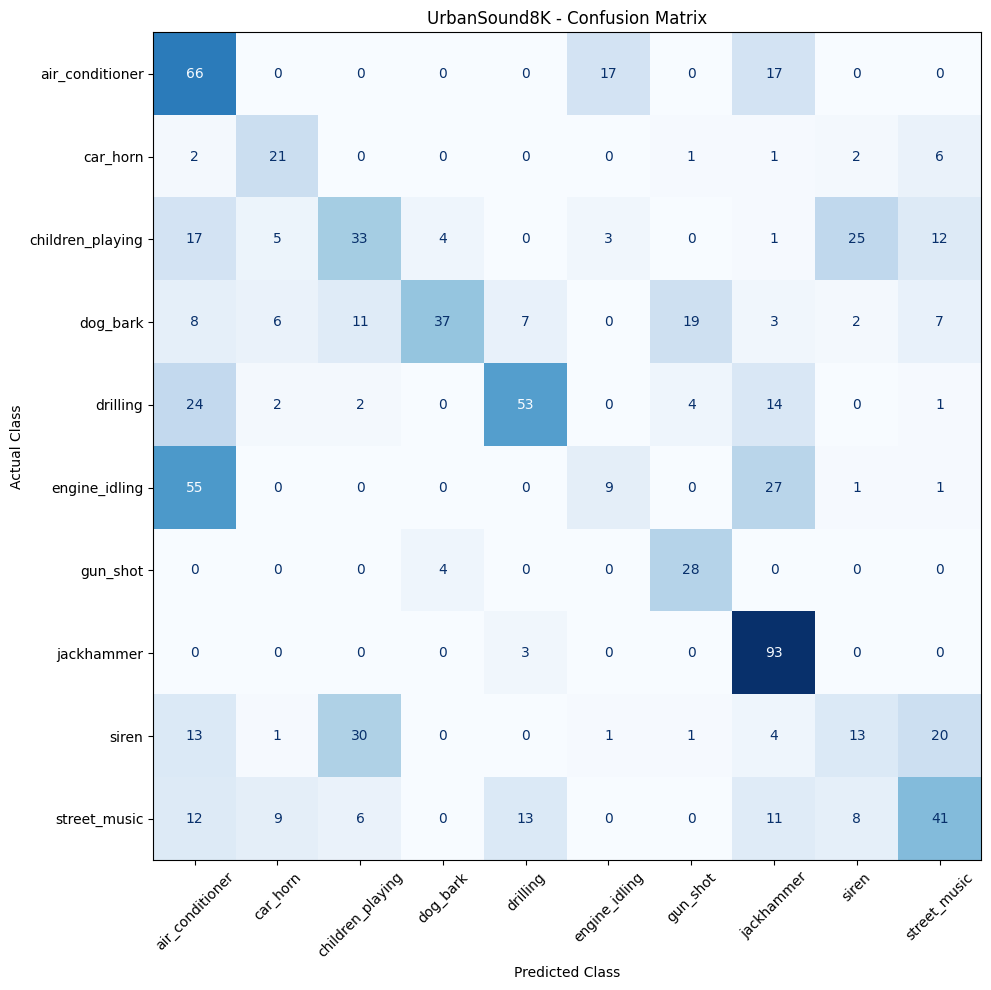

In [73]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(
    all_labels,
    all_predictions
)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues",
    colorbar=False
)

plt.title("UrbanSound8K - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()